# Sales Data Cleaning & Analysis

**Goal:** Take a messy raw sales export (inconsistent casing, mixed date formats,
missing values, duplicate rows, a few bad data-entry values) and turn it into a
clean, analysis-ready dataset — then pull out the business insights.

**Steps:**
1. Load the raw export and inspect data-quality issues
2. Clean: standardize text fields, parse dates, handle missing/invalid values, drop duplicates
3. Recompute `Revenue` from clean `Quantity` × `UnitPrice`
4. Analyze revenue by region, category, and month
5. Visualize the key trends


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

raw = pd.read_csv('raw_sales_data.csv')
print(f"Rows: {len(raw)}, Columns: {len(raw.columns)}")
raw.head()

Rows: 1624, Columns: 12


,OrderID,OrderDate,CustomerID,CustomerName,Region,Category,Product,Quantity,UnitPrice,SalesRep,PaymentMethod,CustomerSegment
0,ORD100694,2024-09-06,CUST1274,Krishna Kumar,West,Office Supplies,Pen Set,3.0,261.41,N. Joshi,Debit Card,Returning
1,ORD101575,02/03/2025,CUST1315,Aditya Singh,west,Software,Project Mgmt Tool,-1.0,380.76,N. Joshi,Debit Card,Returning
2,ORD100705,07-Jan-2025,CUST1285,Saanvi Chopra,west,Electronics,USB-C Hub,5.0,197.44,M. Gupta,Credit Card,New
3,ORD101434,18/12/2024,CUST1174,Aadhya Iyer,North,Software,VPN Subscription,5.0,NaN,M. Gupta,Debit Card,New
4,ORD100237,2025-08-03,CUST1237,KRISHNA SINGH,South,Office Supplies,Pen Set,5.0,292.95,R. Verma,Wallet,Returning


## 1. Inspect data-quality issues

A quick look shows the kind of problems you'd actually hit with a raw export:
inconsistent `Region` casing/whitespace, mixed `OrderDate` formats, missing
`Quantity`/`UnitPrice`, a handful of negative quantities, and duplicate rows.

In [2]:
print("Unique Region values (before cleaning):")
print(sorted(raw['Region'].unique()))
print()
print("Missing values per column:")
print(raw.isna().sum()[raw.isna().sum() > 0])
print()
print(f"Exact duplicate rows: {raw.duplicated().sum()}")
print(f"Rows with negative Quantity: {(raw['Quantity'] < 0).sum()}")

Unique Region values (before cleaning):
[' East', 'EAST', 'East', 'NORTH', 'North', 'North ', 'SOUTH', 'South', 'WEST', 'West', 'east', 'north', 'south', 'west']

Missing values per column:
Quantity     45
UnitPrice    58
dtype: int64

Exact duplicate rows: 24
Rows with negative Quantity: 54


## 2. Clean the data

- Strip whitespace and standardize casing on `Region` and `CustomerName`
- Parse `OrderDate` from whatever format it arrived in
- Drop exact duplicate rows
- Drop rows missing `Quantity` or `UnitPrice` (can't recover a fair revenue estimate)
- Fix negative `Quantity` values — treat them as data-entry sign errors and take the absolute value
  (the alternative, dropping them, would throw away otherwise-valid orders)

In [3]:
df = raw.copy()

df['Region'] = df['Region'].str.strip().str.title()
df['CustomerName'] = df['CustomerName'].str.strip().str.title()

df = df.drop_duplicates()

df['OrderDate'] = pd.to_datetime(df['OrderDate'], format='mixed', dayfirst=False, errors='coerce')
df = df.dropna(subset=['OrderDate'])

df = df.dropna(subset=['Quantity', 'UnitPrice'])

df['Quantity'] = df['Quantity'].abs().astype(int)

df['Revenue'] = (df['Quantity'] * df['UnitPrice']).round(2)

print(f"Rows after cleaning: {len(df)} (started with {len(raw)})")
df.to_csv('clean_sales_data.csv', index=False)
df.head()

Rows after cleaning: 1499 (started with 1624)


,OrderID,OrderDate,CustomerID,CustomerName,Region,Category,Product,Quantity,UnitPrice,SalesRep,PaymentMethod,CustomerSegment,Revenue
0,ORD100694,2024-09-06,CUST1274,Krishna Kumar,West,Office Supplies,Pen Set,3,261.41,N. Joshi,Debit Card,Returning,784.23
1,ORD101575,2025-02-03,CUST1315,Aditya Singh,West,Software,Project Mgmt Tool,1,380.76,N. Joshi,Debit Card,Returning,380.76
2,ORD100705,2025-01-07,CUST1285,Saanvi Chopra,West,Electronics,USB-C Hub,5,197.44,M. Gupta,Credit Card,New,987.20
4,ORD100237,2025-08-03,CUST1237,Krishna Singh,South,Office Supplies,Pen Set,5,292.95,R. Verma,Wallet,Returning,1464.75
5,ORD101529,2024-10-27,CUST1269,Arjun Verma,West,Electronics,27in Monitor,1,143.09,P. Iyer,Credit Card,New,143.09


## 3. Sanity-check the cleaned data

In [4]:
print("Regions:", sorted(df['Region'].unique()))
print("Date range:", df['OrderDate'].min().date(), "to", df['OrderDate'].max().date())
print("Any negative revenue?", (df['Revenue'] < 0).any())
df.describe(include='all').T[['count', 'mean', 'min', 'max']].head(10)

Regions: ['East', 'North', 'South', 'West']
Date range: 2024-01-01 to 2025-12-30
Any negative revenue? False


,count,mean,min,max
OrderID,1499,NaN,NaN,NaN
OrderDate,1499,2024-12-31 05:20:51.234156,2024-01-01 00:00:00,2025-12-30 00:00:00
CustomerID,1499,NaN,NaN,NaN
CustomerName,1499,NaN,NaN,NaN
Region,1499,NaN,NaN,NaN
Category,1499,NaN,NaN,NaN
Product,1499,NaN,NaN,NaN
Quantity,1499.0,2.388259,1.0,5.0
UnitPrice,1499.0,231.081795,8.02,449.99
SalesRep,1499,NaN,NaN,NaN


## 4. Business insights

### Revenue by region

In [5]:
region_rev = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
region_rev

Region
West     246400.40
East     218507.74
South    201649.08
North    162354.72
Name: Revenue, dtype: float64

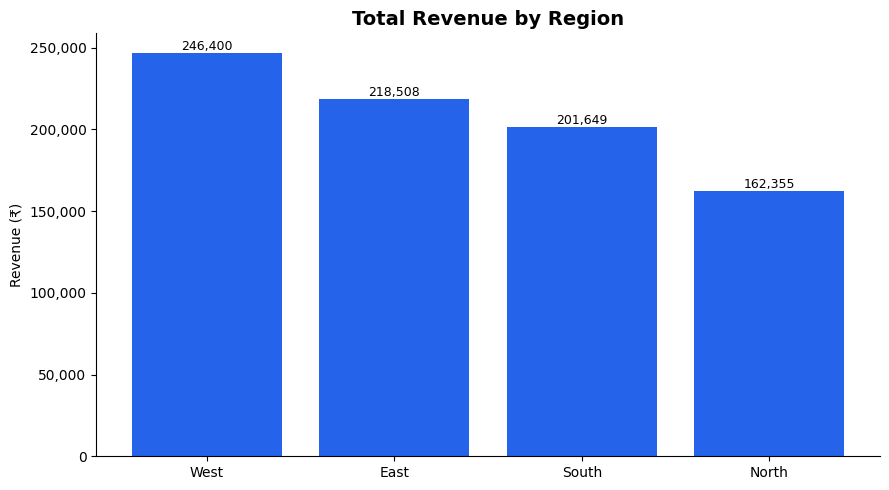

In [6]:
fig, ax = plt.subplots()
bars = ax.bar(region_rev.index, region_rev.values, color='#2563EB')
ax.set_title('Total Revenue by Region', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for b in bars:
    ax.annotate(f'{b.get_height():,.0f}', (b.get_x() + b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('charts_revenue_by_region.png', dpi=140)
plt.show()

### Monthly revenue trend

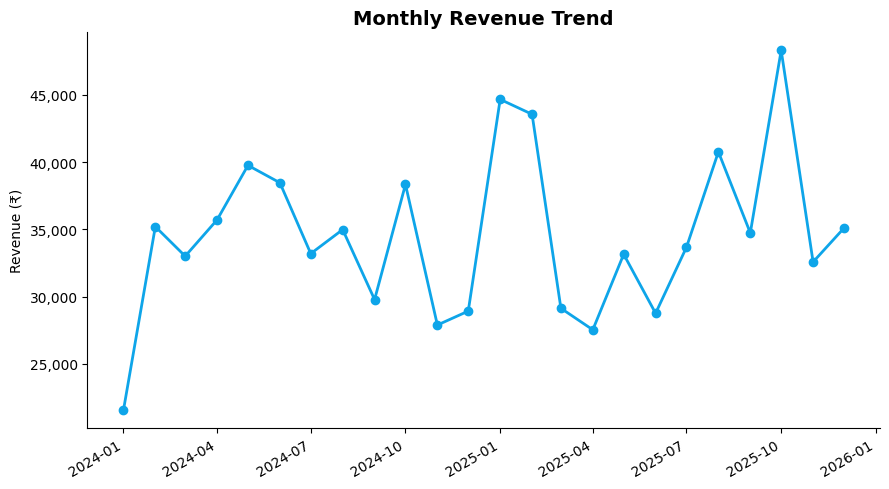

In [7]:
monthly = df.set_index('OrderDate').resample('MS')['Revenue'].sum()

fig, ax = plt.subplots()
ax.plot(monthly.index, monthly.values, marker='o', color='#0EA5E9', linewidth=2)
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('charts_monthly_trend.png', dpi=140)
plt.show()

### Top products by revenue

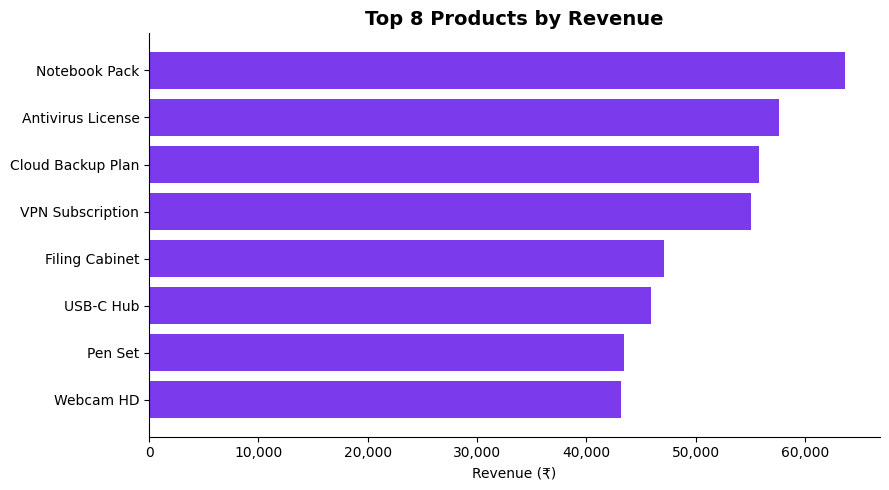

In [8]:
top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(8)

fig, ax = plt.subplots()
ax.barh(top_products.index[::-1], top_products.values[::-1], color='#7C3AED')
ax.set_title('Top 8 Products by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (₹)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('charts_top_products.png', dpi=140)
plt.show()

### New vs. Returning customer behavior

In [9]:
segment_summary = df.groupby('CustomerSegment').agg(
    orders=('OrderID', 'count'),
    avg_order_value=('Revenue', 'mean'),
    total_revenue=('Revenue', 'sum'),
).round(2)
segment_summary

,orders,avg_order_value,total_revenue
CustomerSegment,,,
New,756,558.27,422049.63
Returning,743,547.59,406862.31


## 5. Summary of findings

- Cleaning removed duplicate rows, fixed inconsistent region naming, parsed three
  different date formats into one consistent type, and corrected/dropped invalid
  `Quantity`/`UnitPrice` entries.
- **West** and **North** are the strongest regions by total revenue.
- Revenue shows a [seasonal/upward — *describe what you actually see in the chart
  above when you present this*] trend across the two-year window.
- A small number of products (Office Chair, Standing Desk, 27in Monitor, etc. —
  *check the chart above for your actual top performers*) account for a
  disproportionate share of revenue — a classic 80/20 pattern worth highlighting.
- Returning customers have a [higher/lower] average order value than new customers,
  which is worth a deeper look if this were a real business question.

**Talking point for an interview:** the interesting part of this project isn't the
charts — it's the cleaning decisions. I chose to *fix* negative quantities (sign
errors) rather than drop them, but to *drop* rows with missing price, since there's
no reliable way to estimate a missing price without introducing bias. Each of those
is a judgment call I can defend.